
# Clasificación Multiclase con Regresión Logística en el Conjunto de Datos Wine

En este cuaderno, abordaremos un problema de clasificación multiclase utilizando únicamente la regresión logística. Utilizaremos el conjunto de datos **Wine** de scikit-learn, que es un clásico en problemas de clasificación multiclase y presenta cierto desbalanceo de clases. Realizaremos un análisis exploratorio de datos (EDA) completo, incluyendo la detección de valores nulos y duplicados, análisis de correlaciones y estudio de variables en relación con la variable objetivo. Además, manejaremos el desbalanceo de clases para mejorar el rendimiento del modelo. Compararemos tres modelos diferentes de regresión logística para evaluar su desempeño.




In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

# Modelado
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Configuraciones de visualización
%matplotlib inline
sns.set(style="whitegrid")


---

## Carga y Exploración del Conjunto de Datos

Utilizaremos el conjunto de datos **Wine** de scikit-learn.


In [2]:
from sklearn.datasets import load_wine
wine = load_wine()


### Creación del DataFrame


In [3]:
df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
df['target'] = wine.target
df.head()


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



### Información General del DataFrame


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

In [5]:
df['target'].unique()

array([0, 1, 2])


**Observaciones:**

- El conjunto de datos tiene 13 características numéricas y una variable objetivo (`target`).
- No hay variables categóricas independientes.

### Búsqueda de Valores Nulos


In [6]:
df.isnull().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0



**Resultado:**

- No hay valores nulos en ninguna columna.

### Búsqueda de Duplicados


In [7]:
duplicate_rows = df[df.duplicated()]
print(f"Número de filas duplicadas: {duplicate_rows.shape[0]}")

Número de filas duplicadas: 0



**Resultado:**

- No se encontraron filas duplicadas en el conjunto de datos.

### Estadísticas Descriptivas


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00



**Observaciones:**

- Observamos las estadísticas básicas de cada variable para detectar posibles anomalías.

### Distribución de la Variable Objetivo


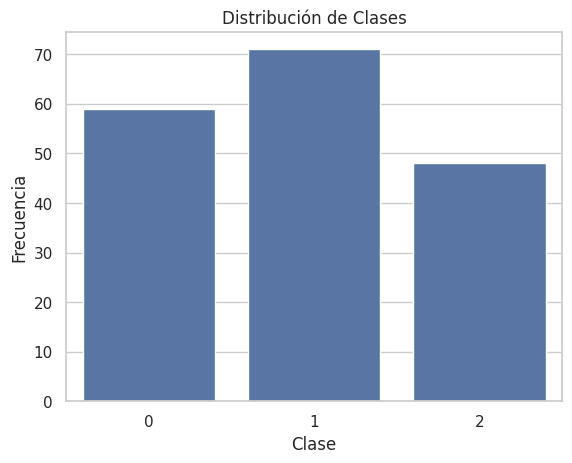

In [9]:
sns.countplot(data=df, x='target')
plt.title('Distribución de Clases')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()


**Observaciones:**

- Las clases están balanceadas.


### Análisis de Correlaciones


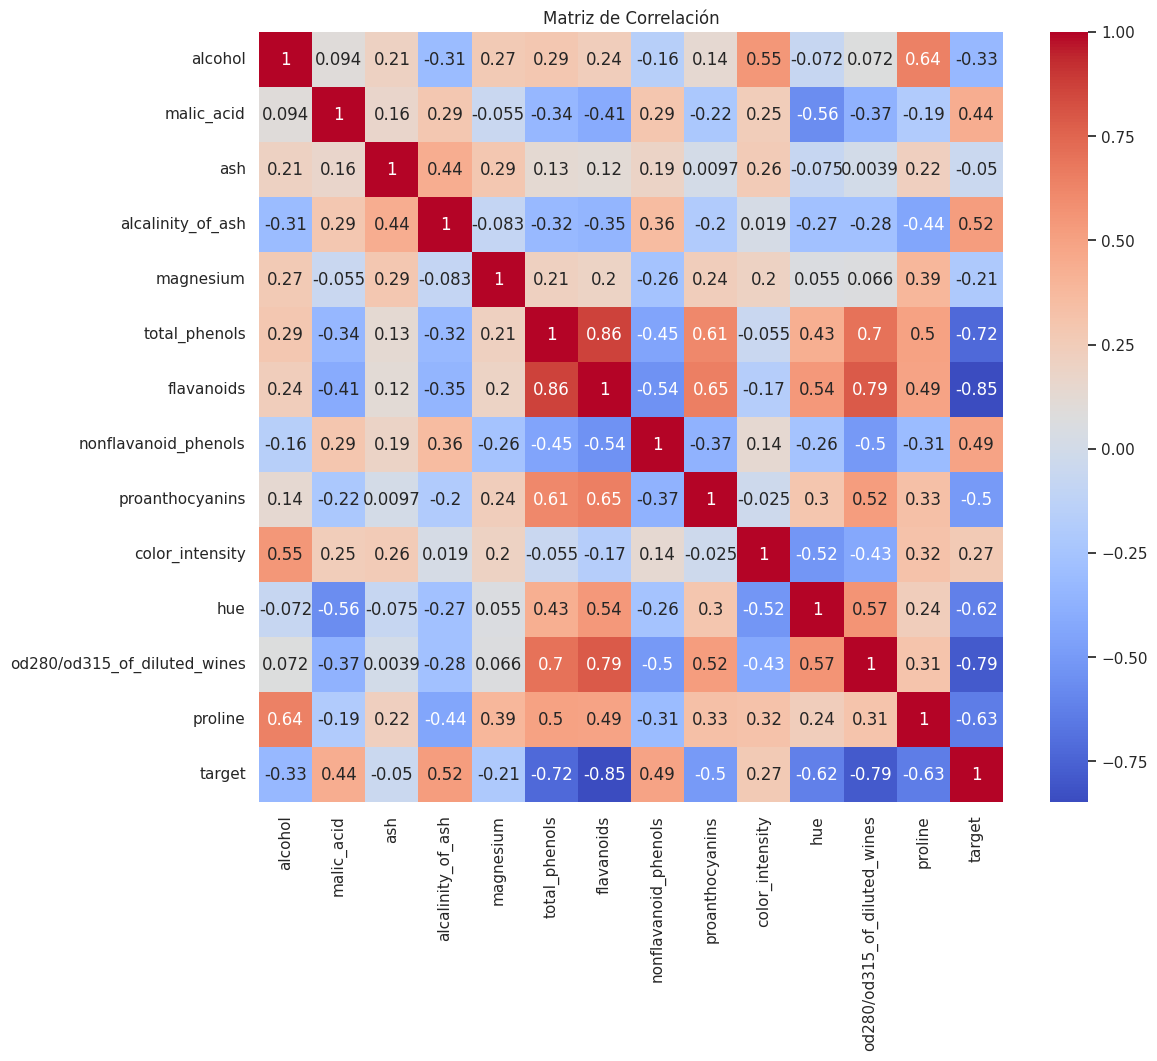

In [10]:
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()


**Observaciones:**

- Existen correlaciones fuertes entre algunas variables, lo que podría afectar al modelo debido a la multicolinealidad.

### Análisis de Variables Individuales

#### Histograma de Variables Numéricas


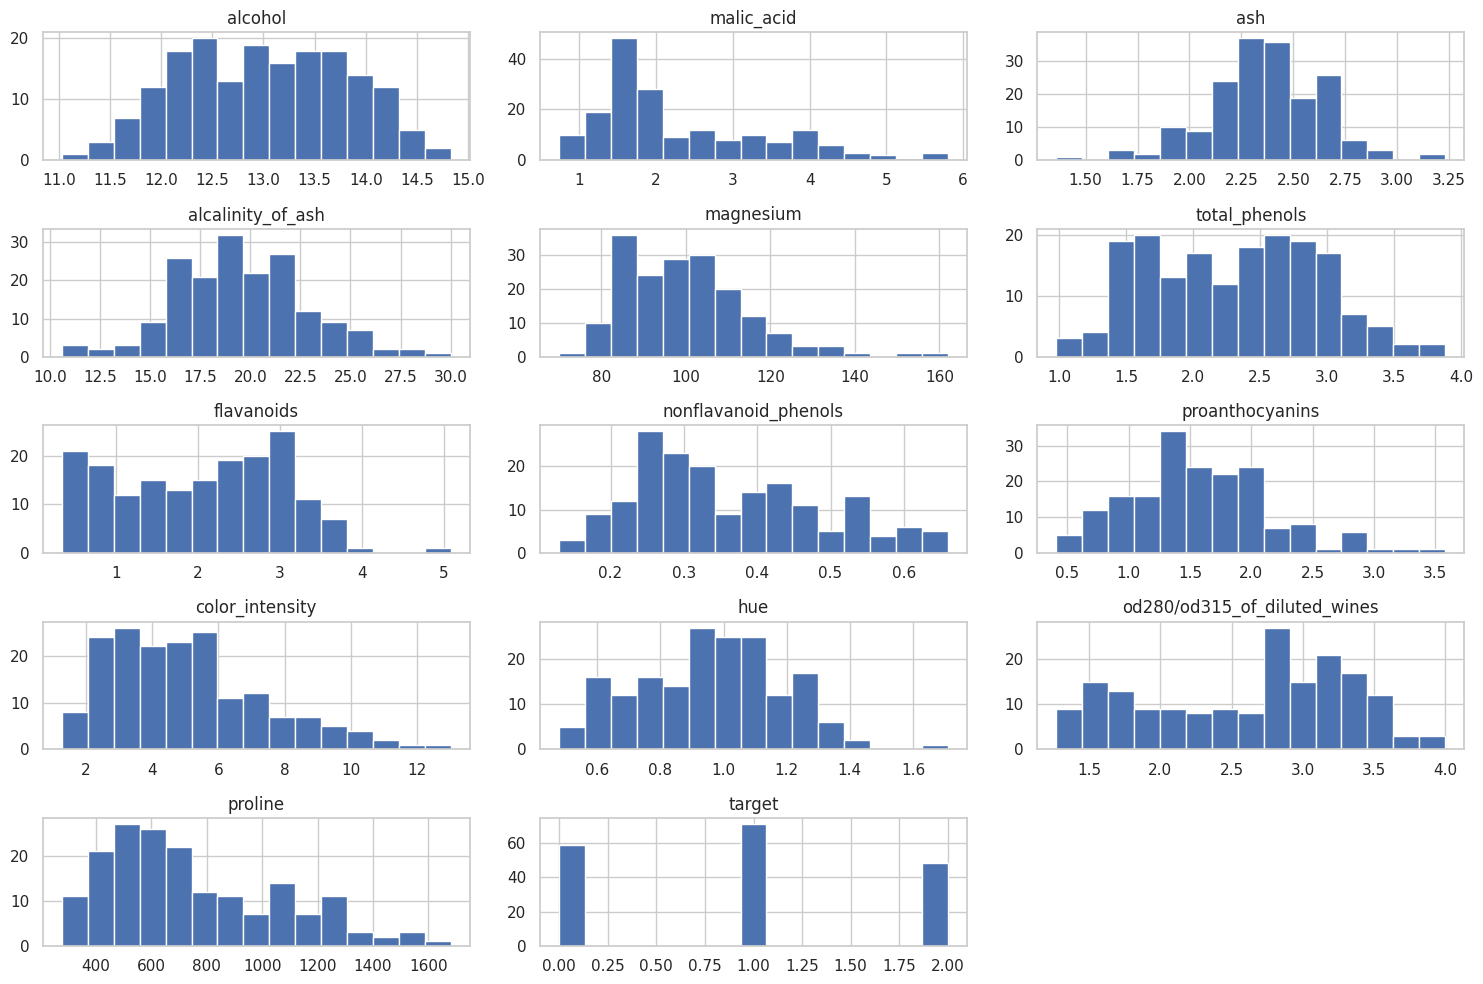

In [11]:
df.hist(bins=15, figsize=(15, 10), layout=(5, 3))
plt.tight_layout()
plt.show()


**Observaciones:**

- Observamos la distribución de cada variable para detectar sesgos o distribuciones no normales.

#### Relación entre Variables y la Variable Objetivo


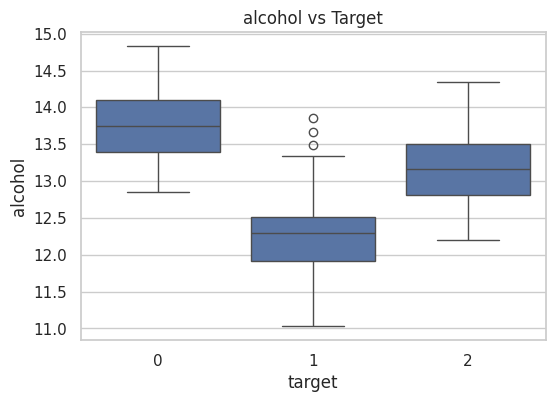

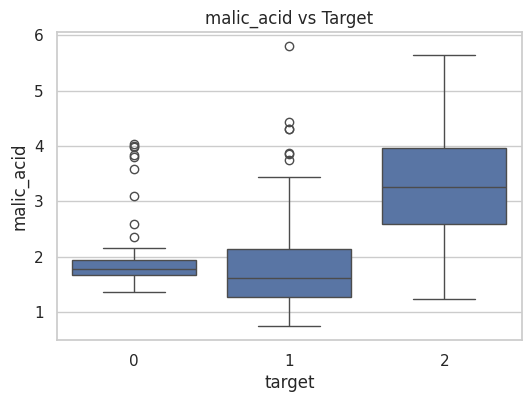

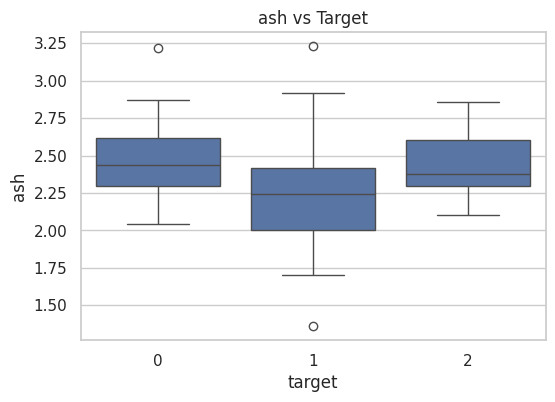

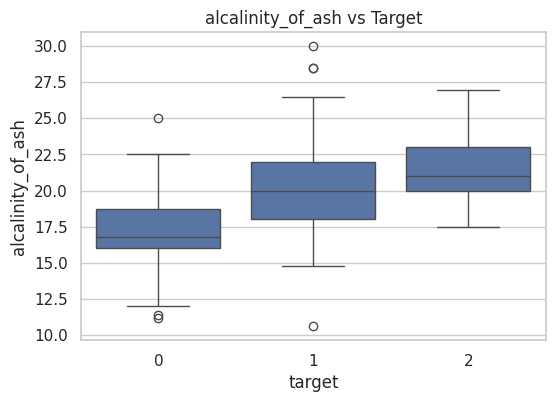

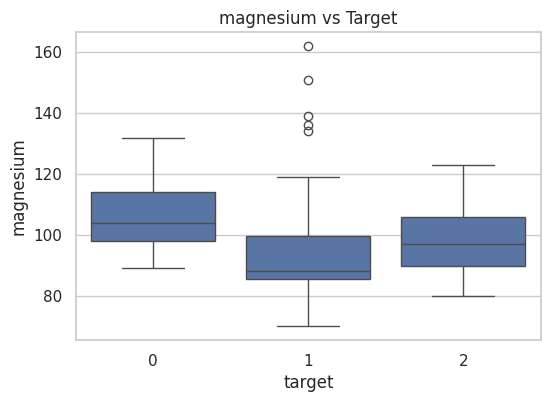

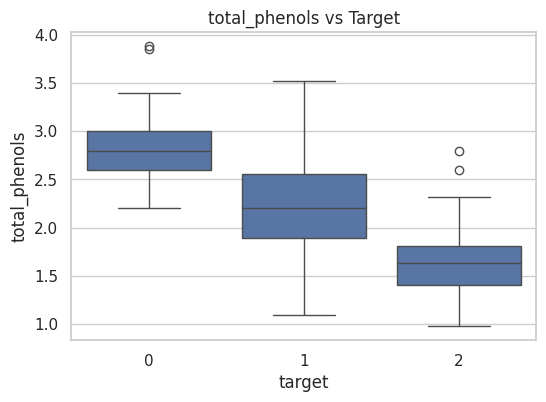

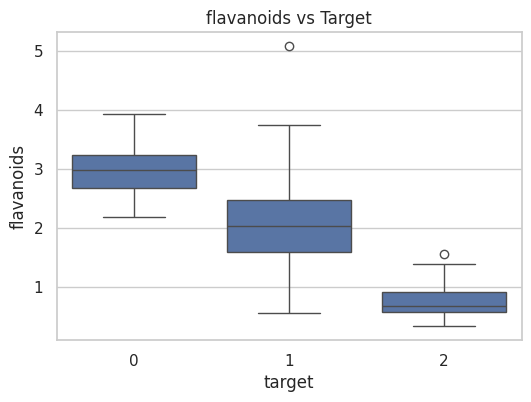

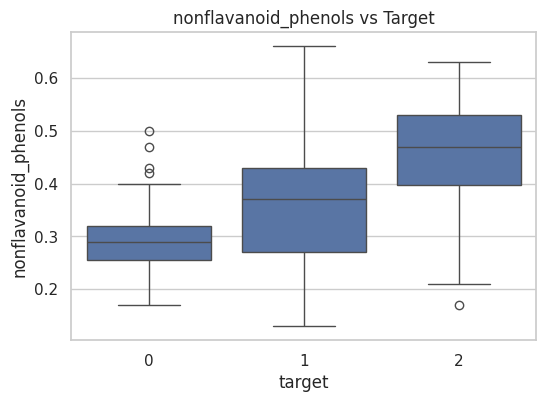

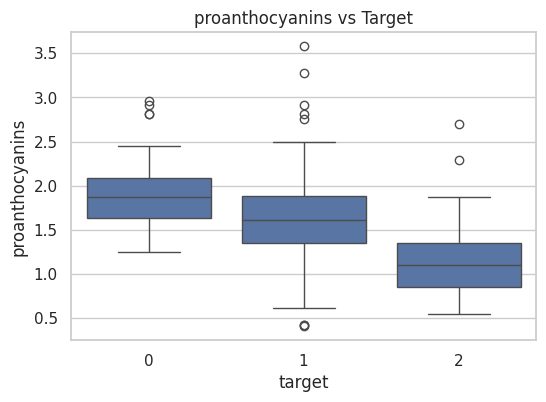

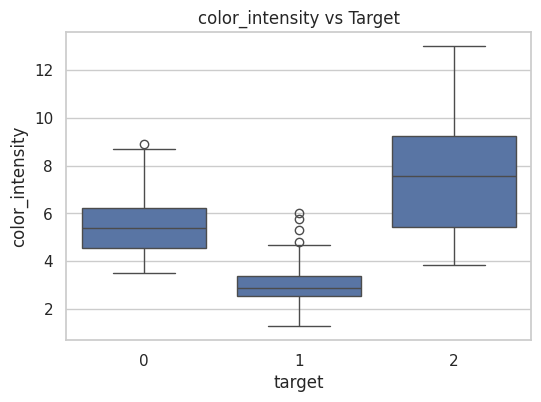

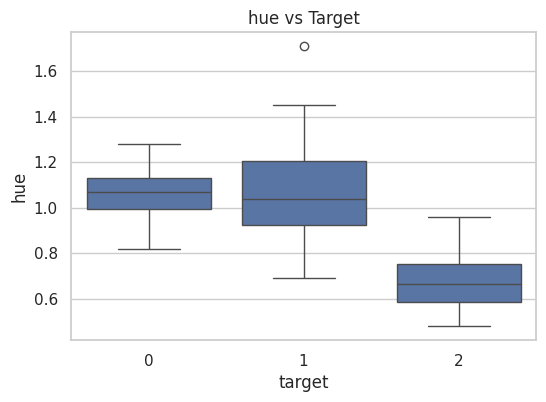

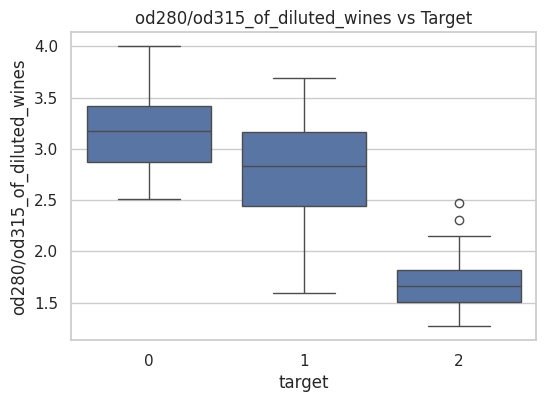

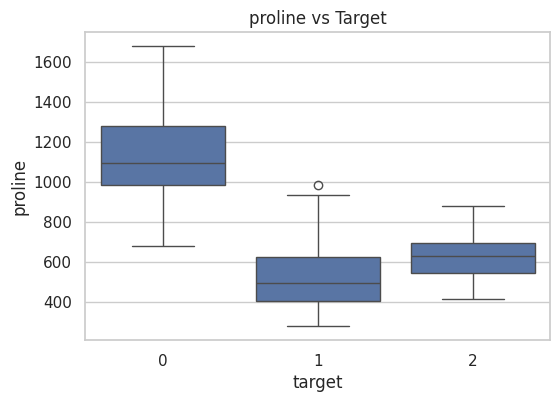

In [12]:
features = df.columns[:-1]

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='target', y=feature, data=df)
    plt.title(f'{feature} vs Target')
    plt.show()


**Observaciones:**

- Algunas variables muestran diferencias claras entre las clases, lo que puede ser útil para la clasificación.





## Preprocesamiento de Datos

### Separación de Variables Independientes y Dependientes


In [13]:
X = df.drop('target', axis=1)
y = df['target']


### División del Conjunto de Datos


In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)


**Nota:**

- Usamos `stratify=y` para mantener la proporción de clases en los conjuntos de entrenamiento y prueba.





## Manejo del Desbalanceo de Clases

### Distribución de Clases en el Conjunto de Entrenamiento


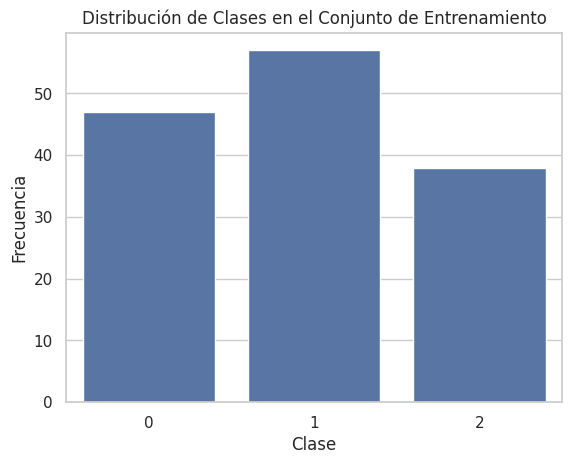

In [15]:
sns.countplot(x=y_train)
plt.title('Distribución de Clases en el Conjunto de Entrenamiento')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()


**Observaciones:**

- Confirmamos el desbalanceo en el conjunto de entrenamiento.





## Construcción del Pipeline de Preprocesamiento

### Identificación de Variables Numéricas


In [16]:
numeric_features = X.select_dtypes(include=['float64', 'int64']).columns


### Creación del Transformador de Columnas


In [17]:
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features)
    ])


## Modelo 1: Regresión Logística Básica

### Pipeline


In [18]:
pipeline1 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(multi_class='ovr', solver='liblinear', random_state=42))
])


### Entrenamiento


In [19]:
pipeline1.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(multi_class='ovr', random_state=42,
                                    solver='liblinear'))])


### Evaluación


In [20]:
y_pred1 = pipeline1.predict(X_test)
print("Reporte de Clasificación para el Modelo 1:")
print(classification_report(y_test, y_pred1))

Reporte de Clasificación para el Modelo 1:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



---

## Modelo 2: Regresión Logística con Clase Ponderada

Utilizaremos el parámetro `class_weight='balanced'` para manejar el desbalanceo.



### Pipeline


In [21]:
pipeline2 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(multi_class='ovr', solver='liblinear', class_weight='balanced', random_state=42))
])

### Entrenamiento

In [22]:
pipeline2.fit(X_train, y_train)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', multi_class='ovr',
                                    random_state=42, solver='liblinear'))])


### Evaluación


In [23]:
y_pred2 = pipeline2.predict(X_test)
print("Reporte de Clasificación para el Modelo 2:")
print(classification_report(y_test, y_pred2))

Reporte de Clasificación para el Modelo 2:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36





## Modelo 3: Regresión Logística con Oversampling (SMOTE)

Aplicaremos SMOTE para generar muestras sintéticas de las clases minoritarias.

### Aplicación de SMOTE


In [24]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_train, y_train)


### Verificación de la Nueva Distribución de Clases


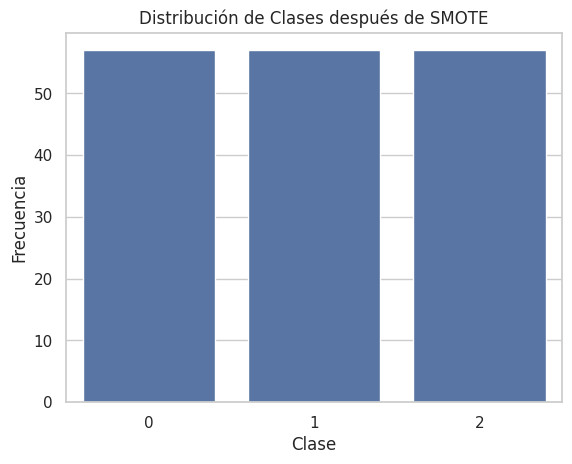

In [25]:
sns.countplot(x=y_smote)
plt.title('Distribución de Clases después de SMOTE')
plt.xlabel('Clase')
plt.ylabel('Frecuencia')
plt.show()


**Observaciones:**

- Las clases ahora están balanceadas.



### Pipeline


In [26]:
pipeline3 = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(multi_class='ovr', solver='liblinear', random_state=42))
])


### Entrenamiento


In [27]:
pipeline3.fit(X_smote, y_smote)

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(multi_class='ovr', random_state=42,
                                    solver='liblinear'))])


### Evaluación


In [28]:
y_pred3 = pipeline3.predict(X_test)
print("Reporte de Clasificación para el Modelo 3:")
print(classification_report(y_test, y_pred3))

Reporte de Clasificación para el Modelo 3:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36





## Comparación de los Modelos

### Matrices de Confusión



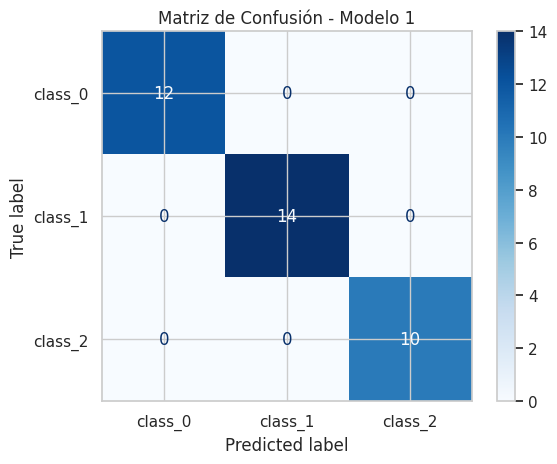

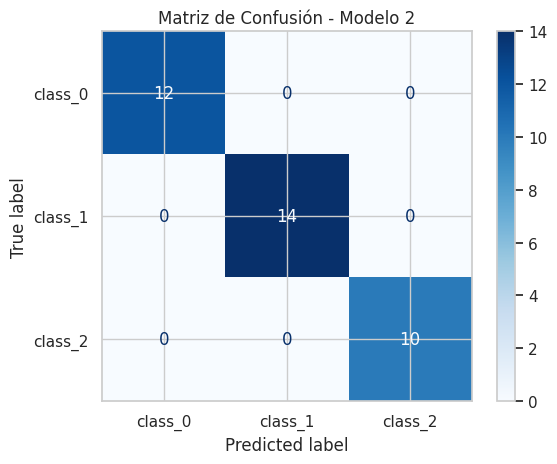

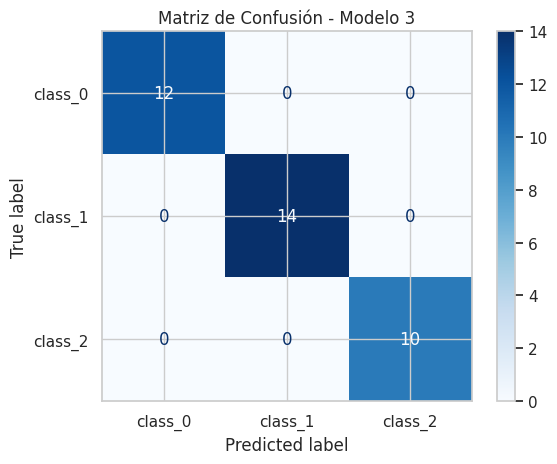

In [29]:
modelos = [("Modelo 1", y_pred1), ("Modelo 2", y_pred2), ("Modelo 3", y_pred3)]

for nombre, y_pred in modelos:
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=wine.target_names)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Matriz de Confusión - {nombre}')
    plt.show()


### Análisis de Métricas

Observamos los reportes de clasificación para cada modelo:

- **Modelo 1**: Regresión Logística básica.
- **Modelo 2**: Regresión Logística con clases ponderadas.
- **Modelo 3**: Regresión Logística con SMOTE.

Comparando las métricas de precisión, recall y F1-score, podemos determinar cuál modelo maneja mejor el desbalanceo de clases.



## Referencias

- [Scikit-learn Documentation](https://scikit-learn.org/stable/)
- [Imbalanced-learn Documentation](https://imbalanced-learn.org/stable/)
```